In [1]:
import numpy as np
np.__version__

'1.26.4'

In [2]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

In [3]:
import cv2
import os
from tqdm import tqdm
import pandas as pd
import gc

**Разделение видео на кадры**

Используя OpenCV библиотеку, получаем отдельные кадры видео.

In [1]:
def extract_frames(video_path, skip_frames=5):
    """
    Args:
        video_path: video URL or path
        skip_frames: exctract only one of N frames
    
    Returns:
        tuple (delta_t, frames):
            delta_t: time between frames exctracted
            frames: np.array of frames
    """
    cap = cv2.VideoCapture(video_path)
    
    frames = []
    frame_count = 0
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    delta_t = skip_frames / cap.get(cv2.CAP_PROP_FPS)
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        if frame_count % skip_frames == 0:
            frames.append(frame)
        
        frame_count += 1
    
    cap.release()
    #print(f"Frame count: {frame_count}")
    #print(f"Frames appended: {len(frames)} (each {skip_frames})")
    
    return delta_t, frames

def split_into_segments(frames, segment_length=10):
    """
    Args:
        frames: array of frames
        segment_length: how much frames in one split
    
    Returns:
        array of segments, each contains np.array of frames
    """
    segments = []
    num_segments = len(frames) // segment_length
    
    for i in range(num_segments):
        start = i * segment_length
        end = start + segment_length
        segment = frames[start:end]
        segments.append(segment)
        
    remainder = len(frames) % segment_length
    if remainder > 0:
        segments.append(frames[-remainder:])
    
    print(f"Segment count: {len(segments)}")
    return segments

In [63]:
import albumentations as A

#аугментации в конечном итоге не использовались

def augment_segment(frames):
    transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.GaussianBlur(p=0.3),
    ])
    
    augmented = transform(images=frames)
    aug_images = augmented["images"]
    return aug_images

**Детекция и получение скелета**

Используется библиотека MediaPipe для детекции скелета человека на видео

In [26]:
landmark_names = [
    'nose',
    'left_eye_inner', 'left_eye', 'left_eye_outer',
    'right_eye_inner', 'right_eye', 'right_eye_outer',
    'left_ear', 'right_ear',
    'mouth_left', 'mouth_right',
    'left_shoulder', 'right_shoulder',
    'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist',
    'left_pinky_1', 'right_pinky_1',
    'left_index_1', 'right_index_1',
    'left_thumb_2', 'right_thumb_2',
    'left_hip', 'right_hip',
    'left_knee', 'right_knee',
    'left_ankle', 'right_ankle',
    'left_heel', 'right_heel',
    'left_foot_index', 'right_foot_index',
]

BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode
model_path = "mediapipe/pose_landmarker_full.task"

def extract_pose_from_segment(segment, delta_t, label, poses=1):
    """
    Returns:
        dataframe (1, 33*3*N)
    """    
    all_landmarks = []
    
    options = PoseLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=model_path),
        running_mode=VisionRunningMode.VIDEO,
        num_poses=poses,
        min_pose_detection_confidence=0.5,
        min_pose_presence_confidence=0.5
    )
    pose_landmarker = PoseLandmarker.create_from_options(options)
    
    for i, frame in enumerate(segment):
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        frame_timestamp_ms = int(i * delta_t * 1000)
        detection_result = pose_landmarker.detect_for_video(mp_image, frame_timestamp_ms)

        if detection_result.pose_landmarks and len(detection_result.pose_landmarks) > 0:
            pose_landmarks = detection_result.pose_landmarks[0]

            landmarks = []
            for landmark in pose_landmarks:
                landmarks.extend([landmark.x, landmark.y, landmark.z])
            all_landmarks.append(landmarks)
        else:
            #0 if no person
            all_landmarks.append([0] * 33 * 3)
    
    # flatten, as we want 33*3*N features for random forest
    flat_features = np.array(all_landmarks).flatten()
    
    column_names = []
    for t in range(len(segment)):
        for name in landmark_names:
            column_names.append(f'{name}_x_t{t}')
            column_names.append(f'{name}_y_t{t}')
            column_names.append(f'{name}_z_t{t}')
    
    # Dataframe
    df = pd.DataFrame([flat_features], columns=column_names)
    df['delta_t'] = delta_t
    df['label'] = label
    
    return df

In [65]:
def get_labels_from_folders(data_path):
    labels = os.listdir(data_path)
    print(f"Found {len(labels)} labels:")
    print(labels)
    return labels

def get_video_paths(data_path, label):
    label_path = data_path+label
    videos = os.listdir(label_path)
    return videos

def process_video_dataset(labels_dir_path, save_dir, skip_frames=4, segment_length=10):
    """
    Process each video of the dataset
    
    Args:
        labels_dir_path: path to every label directory
        skip_frames: process only nth frame
        segment_length: amount of frames in a segment
    
    Returns:
        Dataframe with shape(N, segment_length*33*3)
    """
    
    labels = get_labels_from_folders(labels_dir_path)
    
    for label in tqdm(labels, desc="Labels"):
        videos = get_video_paths(labels_dir_path, label)
        
        for index, video in enumerate(tqdm(videos, desc=f"Videos ({label})", leave=False)):

            video_path =  labels_dir_path+label+"/"+video
            delta_t, frames = extract_frames(video_path, skip_frames)
            segments = split_into_segments(frames, segment_length)
            all_segments_df = []
            
            for segment in segments:
                df = extract_pose_from_segment(segment, delta_t, label)
                all_segments_df.append(df)
                
                #aug_segment = augment_segment(segment)
                #df_aug = extract_pose_from_segment(aug_segment, delta_t, label)
                #all_segments_df.append(df_aug)
            
            if all_segments_df:
                video_df = pd.concat(all_segments_df, ignore_index=True)
                video_df.to_csv(f"{save_dir}/{label}-{index}.csv", index=False)
                del all_segments_df, video_df
                gc.collect()
            else:
                print(f"Warning: No segments extracted from video {video_path}")

In [66]:
data_path_train = "data/verified_data/"
test_path_test = "data/test/test/"
train_btc = "data_btc_10s/"
train_crawl = "data_crawl_10s/"
save_dir = "data/dataFrameSets/verified_data/"
save_dir_test = "data/dataFrameSets/test/"

**Проверка основных функций**

Проверяем экстракцию фреймов и разделение на сегменты

In [43]:
#test
test_video = "data/verified_data/data_btc_10s/hip thrust/58ad2615-4c71-40c3-ad0e-fdc3ef4a331f.mp4"
delta_t, test_frames = extract_frames(test_video, skip_frames=4)
print(f"Frames extracted: {len(test_frames)}")

Frames extracted: 30


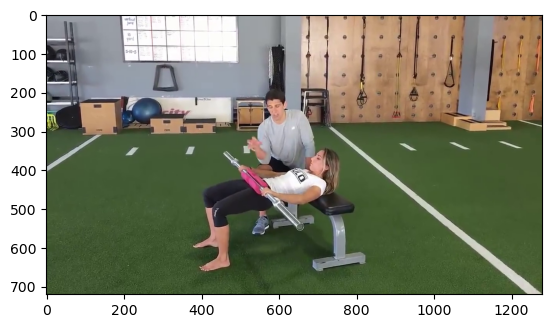

In [64]:
import matplotlib.pyplot as plt
frame_rgb = cv2.cvtColor(test_frames[5], cv2.COLOR_BGR2RGB)
plt.imshow(frame_rgb)

In [45]:
test_segments = split_into_segments(test_frames)

options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=model_path),
    running_mode=VisionRunningMode.VIDEO,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5
)
pose_landmarker = PoseLandmarker.create_from_options(options)

df = extract_pose_from_segment(test_segments[0], delta_t, 'hip thrust')
df

Segment count: 3


,nose_x_t0,nose_y_t0,nose_z_t0,left_eye_inner_x_t0,left_eye_inner_y_t0,left_eye_inner_z_t0,left_eye_x_t0,left_eye_y_t0,left_eye_z_t0,left_eye_outer_x_t0,...,right_heel_y_t9,right_heel_z_t9,left_foot_index_x_t9,left_foot_index_y_t9,left_foot_index_z_t9,right_foot_index_x_t9,right_foot_index_y_t9,right_foot_index_z_t9,delta_t,label
0,0.462768,0.318396,-0.246275,0.466232,0.301791,-0.236807,0.469347,0.300141,-0.236775,0.472571,...,0.869969,-0.075793,0.432938,0.681905,-0.121675,0.308148,0.87244,-0.149508,0.133333,hip thrust


In [58]:
aug_test = augment_segment(test_frames)
aug_test

[array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        ...,
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]]], dtype=uint8),
 array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 

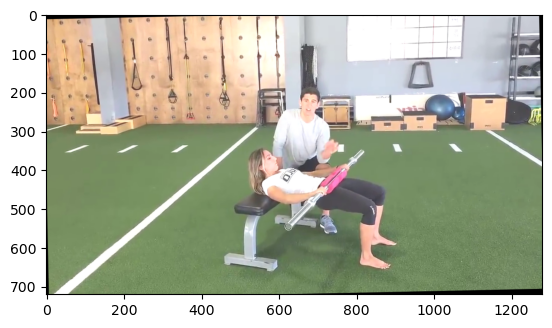

In [62]:
frame_aug_rgb = cv2.cvtColor(aug_test[7], cv2.COLOR_BGR2RGB)
plt.imshow(frame_aug_rgb)

In [22]:
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
from mediapipe.tasks.python import vision


def draw_landmarks_on_image(rgb_image, detection_result):
    pose_landmarks_list = detection_result.pose_landmarks
    annotated_image = np.copy(rgb_image)

    pose_landmark_style = drawing_styles.get_default_pose_landmarks_style()
    pose_connection_style = drawing_utils.DrawingSpec(color=(0, 255, 0), thickness=2)

    for pose_landmarks in pose_landmarks_list:
        drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=pose_landmarks,
        connections=vision.PoseLandmarksConnections.POSE_LANDMARKS,
        landmark_drawing_spec=pose_landmark_style,
        connection_drawing_spec=pose_connection_style)

    return annotated_image

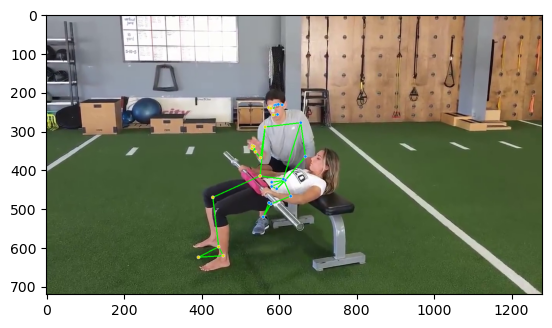

In [13]:
base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    num_poses=2,
    output_segmentation_masks=True)
detector = vision.PoseLandmarker.create_from_options(options)

image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)

detection_result = detector.detect(image)

annotated_image = draw_landmarks_on_image(image.numpy_view(), detection_result)
plt.imshow(annotated_image)

Обрабатываем датасет, и сохраняем датафреймы, по датафрейму на видео

In [67]:
process_video_dataset(data_path_train+train_btc, save_dir)

Found 22 labels:
['barbell biceps curl', 'bench press', 'chest fly machine', 'deadlift', 'decline bench press', 'hammer curl', 'hip thrust', 'incline bench press', 'lat pulldown', 'lateral raise', 'leg extension', 'leg raises', 'plank', 'pull Up', 'push-up', 'romanian deadlift', 'russian twist', 'shoulder press', 'squat', 't bar row', 'tricep dips', 'tricep Pushdown']


Videos (barbell biceps curl):   0%|                                                             | 0/63 [00:00<?, ?it/s]

Segment count: 2



Videos (barbell biceps curl):   2%|▊                                                    | 1/63 [00:01<01:05,  1.06s/it]

Segment count: 6


...


Videos (tricep Pushdown):  96%|█████████████████████████████████████████████████████▊  | 48/50 [01:03<00:03,  1.74s/it]

Segment count: 3



Videos (tricep Pushdown):  98%|██████████████████████████████████████████████████████▉ | 49/50 [01:04<00:01,  1.61s/it]

Segment count: 2



Labels: 100%|██████████████████████████████████████████████████████████████████████████| 22/22 [27:36<00:00, 75.29s/it]


In [69]:
save_dir = "data/dataFrameSets/verified_data_crawl/"
process_video_dataset(data_path_train+train_crawl, save_dir)

Found 22 labels:
['barbell biceps curl', 'bench press', 'chest fly machine', 'deadlift', 'decline bench press', 'hammer curl', 'hip thrust', 'incline bench press', 'lat pulldown', 'lateral raise', 'leg extension', 'leg raises', 'plank', 'pull Up', 'push-up', 'romanian deadlift', 'russian twist', 'shoulder press', 'squat', 't bar row', 'tricep dips', 'tricep Pushdown']


Videos (barbell biceps curl):   0%|                                                             | 0/48 [00:00<?, ?it/s]

Segment count: 7



Videos (barbell biceps curl):   2%|█                                                    | 1/48 [00:03<02:25,  3.09s/it]

Segment count: 7


...


Videos (tricep Pushdown):  88%|█████████████████████████████████████████████████       | 14/16 [00:43<00:05,  2.94s/it]

Segment count: 6



Videos (tricep Pushdown):  94%|████████████████████████████████████████████████████▌   | 15/16 [00:45<00:02,  2.72s/it]

Segment count: 6



Labels: 100%|█████████████████████████████████████████████████████████████████████████| 22/22 [38:48<00:00, 105.84s/it]


In [70]:
save_dir = "data/dataFrameSets/test/"
process_video_dataset(test_path_test, save_dir)

Found 22 labels:
['barbell biceps curl', 'bench press', 'chest fly machine', 'deadlift', 'decline bench press', 'hammer curl', 'hip thrust', 'incline bench press', 'lat pulldown', 'lateral raise', 'leg extension', 'leg raises', 'plank', 'pull Up', 'push-up', 'romanian deadlift', 'russian twist', 'shoulder press', 'squat', 't bar row', 'tricep dips', 'tricep Pushdown']


Videos (barbell biceps curl):   0%|                                                              | 0/2 [00:00<?, ?it/s]

Segment count: 20



Videos (barbell biceps curl):  50%|███████████████████████████                           | 1/2 [00:05<00:05,  5.91s/it]

Segment count: 11


...


Videos (tricep Pushdown):   0%|                                                                  | 0/2 [00:00<?, ?it/s]

Segment count: 11



Videos (tricep Pushdown):  50%|█████████████████████████████                             | 1/2 [00:03<00:03,  3.27s/it]

Segment count: 8



Labels: 100%|██████████████████████████████████████████████████████████████████████████| 22/22 [05:02<00:00, 13.75s/it]
